In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
dataset = load_dataset("yzhuang/metatree_bank8FM")

df = pd.DataFrame(dataset['train'])
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


,id,X,y
0,0,"[-0.102111, -0.193977, -0.385334, 0.257042, 7....",0
1,1,"[0.373578, -0.425602, 0.2895, 0.234217, 2.0285...",1
2,3,"[0.316211, -0.134321, 0.080048, 0.036333, 0.36...",1
3,5,"[0.36613, 0.363605, -0.200576, 0.176573, 9.935...",0
4,6,"[-0.093119, -0.390041, 0.046167, -0.446617, 1....",1


In [ ]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5766 entries, 0 to 5765
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      5766 non-null   int64 
 1   X       5766 non-null   object
 2   y       5766 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 135.3+ KB


Index(['id', 'X', 'y'], dtype='object')

In [ ]:
X_expanded = pd.DataFrame(df['X'].tolist())
X_expanded.columns = [f"f{i}" for i in range(X_expanded.shape[1])]

X_expanded.head()

,f0,f1,f2,f3,f4,f5,f6,f7
0,-0.102111,-0.193977,-0.385334,0.257042,7.188886,15.128160,0.671618,8.0
1,0.373578,-0.425602,0.289500,0.234217,2.028584,2.856180,0.569577,5.0
2,0.316211,-0.134321,0.080048,0.036333,0.360257,1.069743,0.807717,8.0
3,0.366130,0.363605,-0.200576,0.176573,9.935666,1.860283,0.814479,6.0
4,-0.093119,-0.390041,0.046167,-0.446617,1.732547,4.020300,0.842864,6.0


In [ ]:
X = X_expanded
y = df["y"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

print("=== Linear Regression ===")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

=== Linear Regression ===
MSE: 0.09758725247162245
R2 Score: 0.5870452694833903


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

Ridge()

In [ ]:
y_pred_ridge = ridge.predict(X_test_scaled)

print("=== Ridge Regression ===")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

=== Ridge Regression ===
MSE: 0.09757989831822685
R2 Score: 0.5870763896589946


In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

In [ ]:
y_pred_lasso = lasso.predict(X_test_scaled)

print("=== Lasso Regression ===")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))

=== Lasso Regression ===
MSE: 0.11161047818582795
R2 Score: 0.5277039390420266


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

results

,Model,MSE,R2 Score
0,Linear,0.097587,0.587045
1,Ridge,0.097580,0.587076
2,Lasso,0.111610,0.527704


In [ ]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

coeffs

,Feature,Linear,Ridge,Lasso
0,f0,-0.013685,-0.013682,-0.000000
1,f1,0.005215,0.005214,0.000000
2,f2,0.031890,0.031881,0.000000
3,f3,0.005990,0.005987,0.000000
4,f4,-0.240295,-0.240242,-0.139965
5,f5,-0.279280,-0.279219,-0.178655
6,f6,0.036913,0.036907,0.000000
7,f7,0.013434,0.013432,0.000000


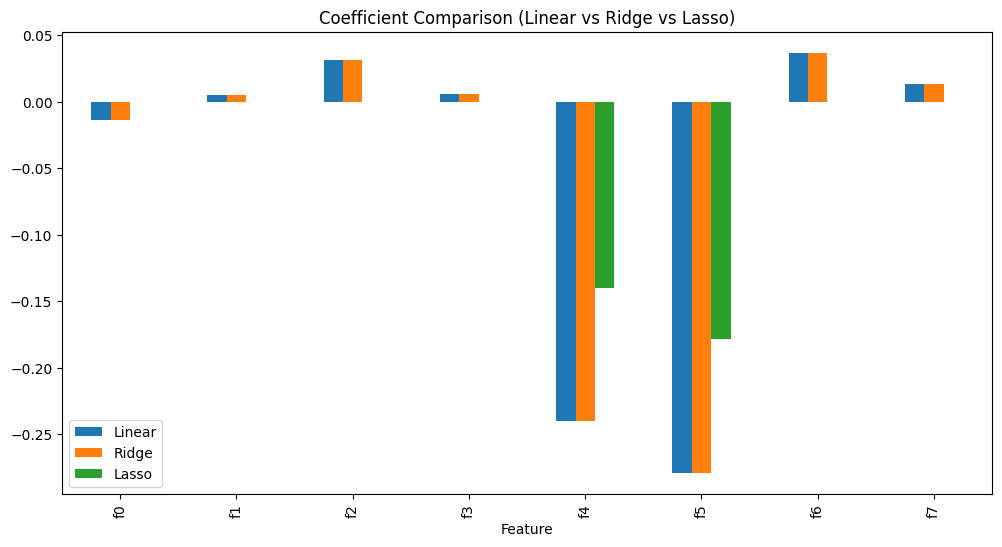

In [ ]:
coeffs.set_index("Feature").plot(kind="bar", figsize=(12,6))
plt.title("Coefficient Comparison (Linear vs Ridge vs Lasso)")
plt.xticks(rotation=90)
plt.show()

## 📝 Implementation of Linear, Ridge, and Lasso Regression

This experiment implements Multiple Linear Regression, Ridge Regression, and Lasso Regression using the dataset **`yzhuang/metatree_bank8FM`** from Hugging Face.

---

### 🔹 1. Importing Libraries
All required libraries are imported in the first cell:
- **pandas, numpy** → data handling  
- **matplotlib, seaborn** → visualization  
- **datasets** → loading dataset  
- **sklearn** → model building and evaluation  

---

### 🔹 2. Loading the Dataset
The dataset is loaded using `load_dataset()` and converted into a Pandas DataFrame.

---

### 🔹 3. Dataset Inspection
We use:
- `df.info()` → to check data types  
- `df.head()` → to preview rows  
- `df.columns` → to understand structure  

Observation:
- `x` → contains feature vectors (stored as sequences)  
- `y` → target variable  
- `id` → identifier (not used in modeling)  

---

### 🔹 4. Feature Engineering
The `x` column contains lists of values. These are expanded into multiple columns (`f0, f1, f2, ...`) so that machine learning models can process them.

---

### 🔹 5. Defining Features and Target
- Features (`X`) = expanded columns from `x`  
- Target (`y`) = `y` column  

---

### 🔹 6. Train-Test Split
The dataset is split into training and testing sets (80% training, 20% testing) to evaluate model performance.

---

### 🔹 7. Feature Scaling
Standardization is applied using `StandardScaler` to ensure all features have similar scale, which is important for Ridge and Lasso regression.

---

### 🔹 8. Multiple Linear Regression
A Linear Regression model is trained without any regularization.  
It assumes a linear relationship between features and target.

---

### 🔹 9. Ridge Regression
Ridge regression adds **L2 regularization**, which penalizes large coefficients and helps reduce overfitting.

---

### 🔹 10. Lasso Regression
Lasso regression uses **L1 regularization**, which can shrink some coefficients to zero, effectively performing feature selection.

---

### 🔹 11. Model Evaluation
All models are evaluated using:
- **Mean Squared Error (MSE)** → measures prediction error  
- **R² Score** → measures how well the model explains variance  

---

### 🔹 12. Model Comparison
The performance of all three models is compared using a table of MSE and R² scores.

---

### 🔹 13. Coefficient Analysis
The coefficients of each model are compared to observe:
- Ridge → shrinks coefficients  
- Lasso → may eliminate some features  

---

### ✅ Conclusion
- Linear Regression provides a baseline model  
- Ridge improves generalization by reducing overfitting  
- Lasso performs feature selection and simplifies the model  

Thus, regularization techniques help improve model performance and interpretability.